<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-placement-insights-ml-100?scriptVersionId=263352096" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/college-student-placement/CollegePlacement.csv


## Student Placement Insights

## Detailed Description:
This project focuses on analyzing and understanding college student placement trends. It explores key factors such as academic performance, technical skills, internships, certifications, and extracurricular activities that influence placement outcomes. By leveraging data visualization and predictive models, the study provides insights into patterns of hiring across different domains, company preferences, and student readiness. The goal is to help students, faculty, and institutions identify strengths, improve training programs, and enhance overall placement success.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/college-student-placement/CollegePlacement.csv")

In [3]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [4]:
df.tail()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No
9999,CLG0060,109,9.41,9.77,8,No,3,5,5,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


In [6]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [7]:
df.isnull().sum()

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

College_ID                 object
IQ                          int64
Prev_Sem_Result           float64
CGPA                      float64
Academic_Performance        int64
Internship_Experience      object
Extra_Curricular_Score      int64
Communication_Skills        int64
Projects_Completed          int64
Placement                  object
dtype: object

In [10]:
df.shape

(10000, 10)

In [11]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

## Data visualizations

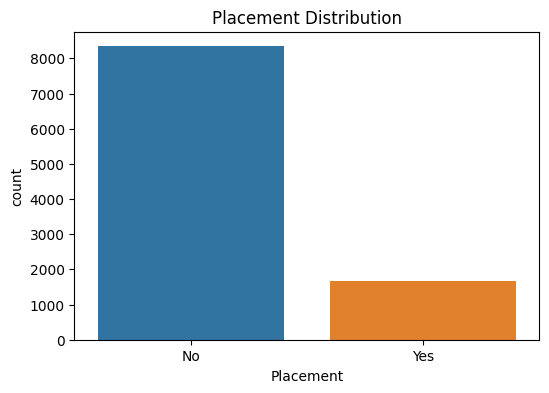

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Placement", data=df)
plt.title("Placement Distribution")
plt.show()

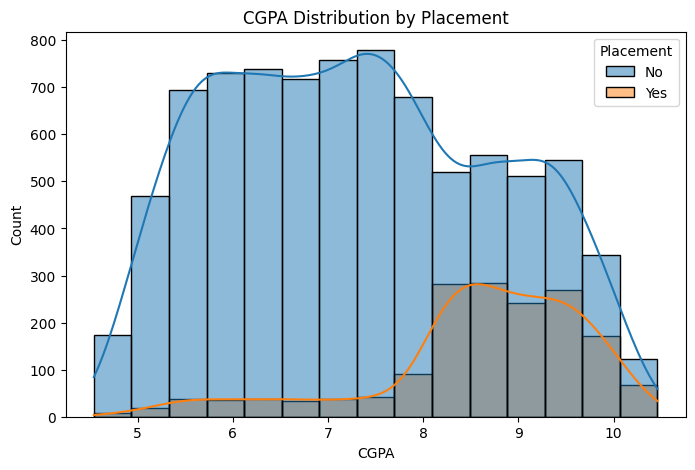

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="CGPA", hue="Placement", kde=True, bins=15)
plt.title("CGPA Distribution by Placement")
plt.show()


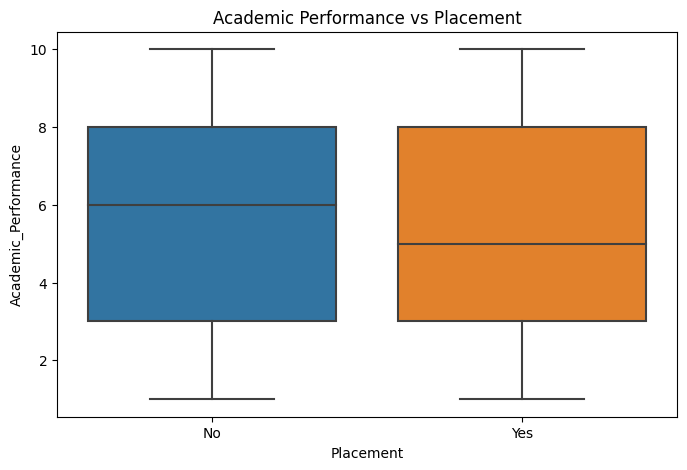

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Placement", y="Academic_Performance", data=df)
plt.title("Academic Performance vs Placement")
plt.show()

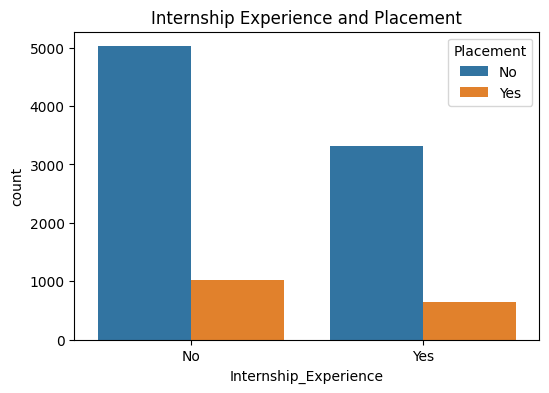

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Internship_Experience", hue="Placement", data=df)
plt.title("Internship Experience and Placement")
plt.show()

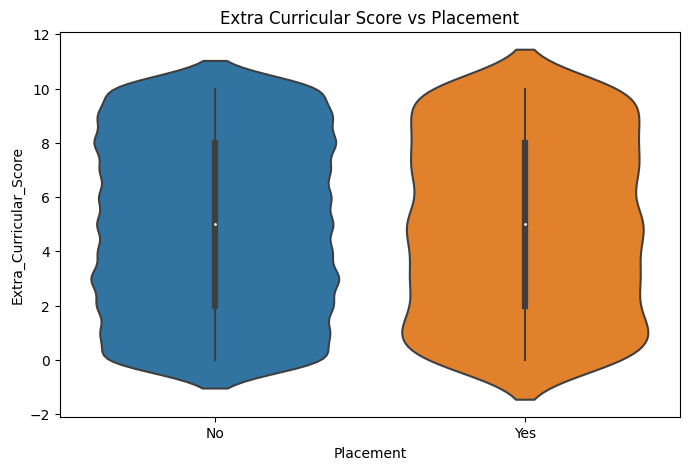

In [16]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Placement", y="Extra_Curricular_Score", data=df)
plt.title("Extra Curricular Score vs Placement")
plt.show()

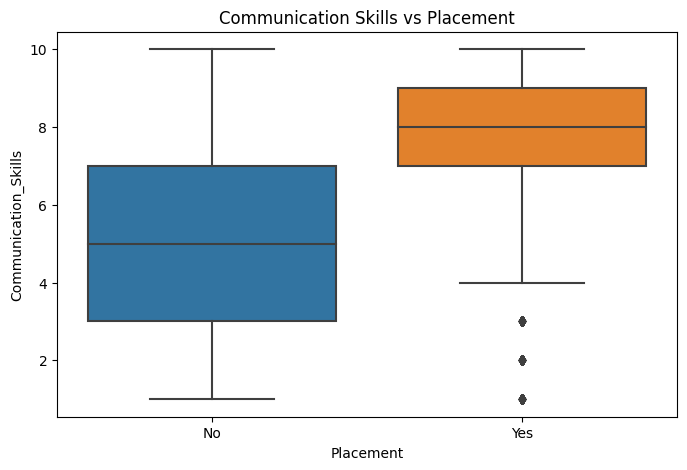

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Placement", y="Communication_Skills", data=df)
plt.title("Communication Skills vs Placement")
plt.show()


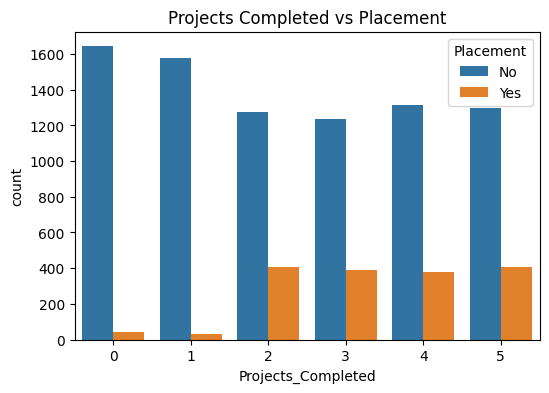

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Projects_Completed", hue="Placement", data=df)
plt.title("Projects Completed vs Placement")
plt.show()

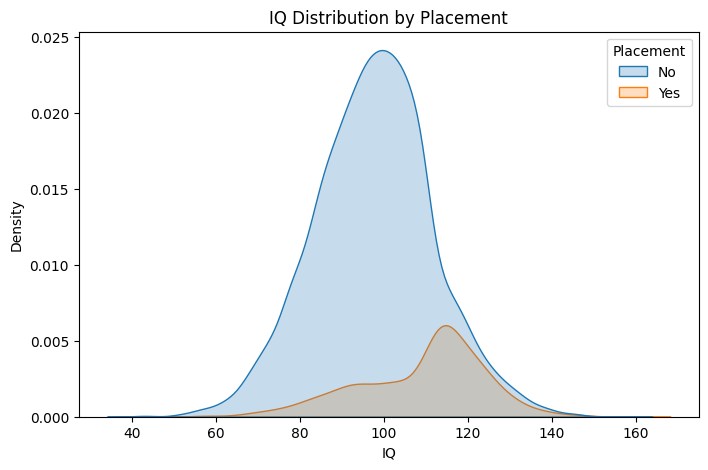

In [19]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="IQ", hue="Placement", fill=True)
plt.title("IQ Distribution by Placement")
plt.show()


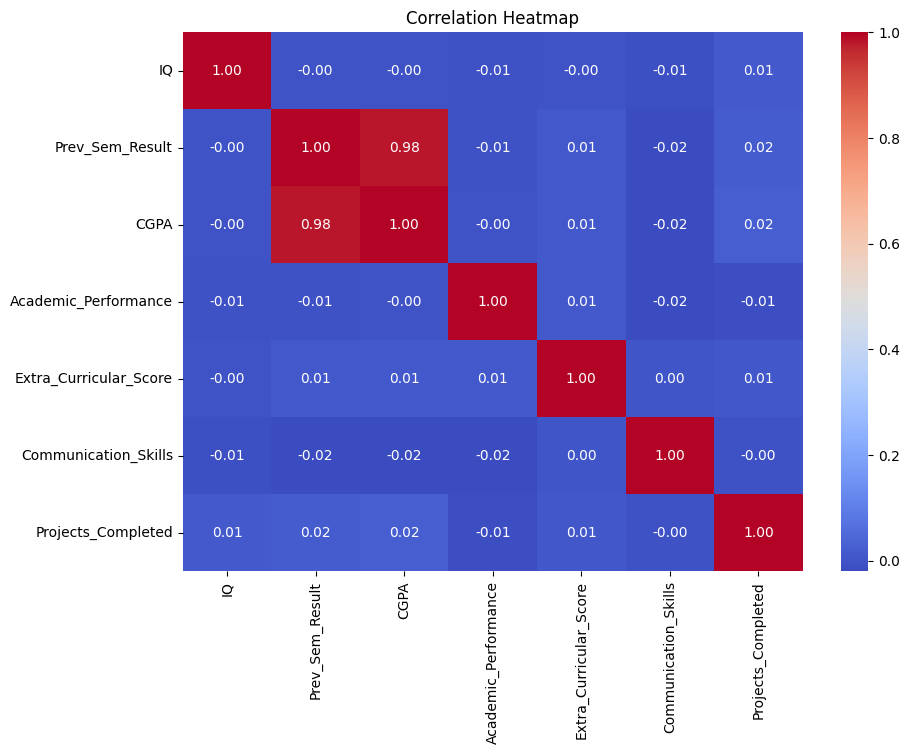

In [20]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## ML Algorithms

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [22]:
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

In [23]:
X = df.drop(columns=['Placement', 'College_ID'])   # drop ID & target
y = df['Placement']

In [24]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

In [26]:
# Train & evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  # percentage
    results[name] = acc


In [27]:
# Convert to DataFrame
results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy (%)"])

In [28]:
print(results_df)


                 Model  Accuracy (%)
0  Logistic Regression         90.35
1        Decision Tree        100.00
2        Random Forest         99.90
3    Gradient Boosting        100.00
4                  KNN         94.80
5                  SVM         95.75
6          Naive Bayes         90.35


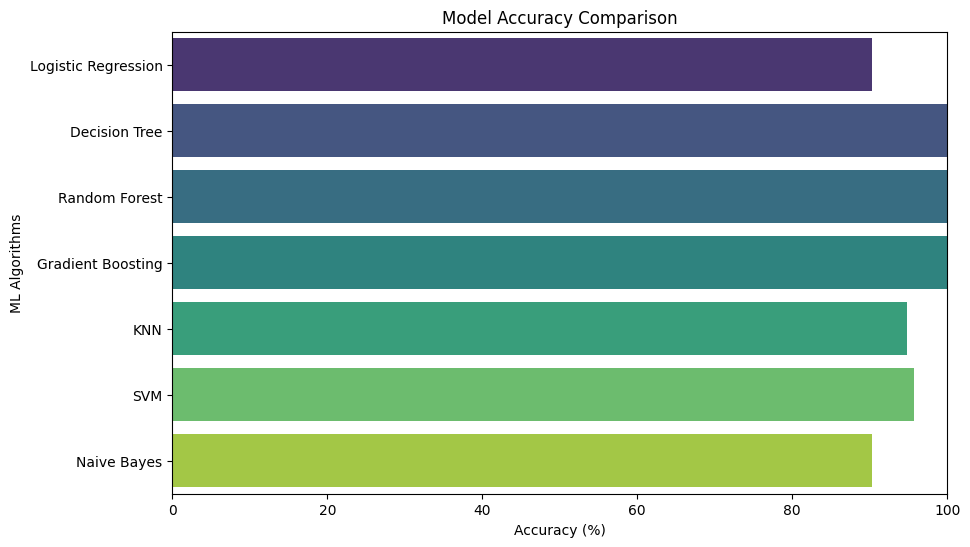

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x="Accuracy (%)", y="Model", data=results_df, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy (%)")
plt.ylabel("ML Algorithms")
plt.xlim(0, 100)
plt.show()

## THank you..pls upvote!!!